*Libraries*

In [63]:
!pip install opencv-python

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
   ---- ----------------------------------- 4.7/40.2 MB 18.8 MB/s eta 0:00:02
   ----- ---------------------------------- 5.8/40.2 MB 12.7 MB/s eta 0:00:03
   ---------- ----------------------------- 10.5/40.2 MB 15.9 MB/s eta 0:00:02
   ------------- -------------------------- 13.1/40.2 MB 16.1 MB/s eta 0:00:02
   -------------------- ------------------- 21.0/40.2 MB 19.2 MB/s eta 0:00:02
   -------------------------- ------------- 26.2/40.2 MB 20.6 MB/s eta 0:00:01
   ----------------------------- ---------- 29.4/40.2 MB 20.0 MB/s eta 0:00:01
   ----------------------------- ---------- 29.9/40.2 MB 19.1 MB/s eta 0:00:01
   ------------------------------- -------- 31.5/40.2 MB 16.7 MB/s eta 0:00:01
   --------------------------------- ------ 33.8/40.2 MB 15.7 MB/s eta 0:00:01
   ------------------------------------ --- 37.0/40.2 MB 15.6 MB/s eta 0

In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

*Data load*

In [2]:
training_set=tf.keras.utils.image_dataset_from_directory(
    "C:\\Users\\Lenovo\\Documents\\CropDiseaseDetectionDataset\\New Plant Diseases Dataset(Augmented)\\New Plant Diseases Dataset(Augmented)\\train",
    labels="inferred",#Takes the name of the folders as the labels
    label_mode="categorical",#We have multiclass problem so categorical(e.g. binary or int is also available)
    class_names=None,
    color_mode="rgb",
    batch_size=32,#To speed up the process we can increase the batch size to 64 or 128
    image_size=(128, 128),
    shuffle=True,#If false then data will be feed in alphanumeric order
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    # format="tf",
    verbose=True,
)


Found 70295 files belonging to 38 classes.


In [5]:
validation_set=tf.keras.utils.image_dataset_from_directory(
    "C:\\Users\\Lenovo\\Documents\\CropDiseaseDetectionDataset\\New Plant Diseases Dataset(Augmented)\\New Plant Diseases Dataset(Augmented)\\valid",
    labels="inferred",#Takes the name of the folders as the labels
    label_mode="categorical",#We have multiclass problem so categorical(e.g. binary or int is also available)
    class_names=None,
    color_mode="rgb",
    batch_size=32,#To speed up the process we can increase the batch size to 64 or 128
    image_size=(128, 128),
    shuffle=True,#If false then data will be feed in alphanumeric order
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    # format="tf",
    verbose=True,
)

Found 17572 files belonging to 38 classes.


In [8]:
for x,y in training_set:
  print(x,x.shape)
  print(y,y.shape)
  break

tf.Tensor(
[[[[116.25 118.25 143.25]
   [118.25 120.25 145.25]
   [127.25 129.25 154.25]
   ...
   [100.25  99.25 130.25]
   [ 84.25  83.25 114.25]
   [ 82.5   81.5  112.5 ]]

  [[111.5  113.5  138.5 ]
   [107.5  109.5  134.5 ]
   [108.75 110.75 135.75]
   ...
   [100.    99.   130.  ]
   [102.25 101.25 132.25]
   [ 92.25  91.25 122.25]]

  [[112.5  114.5  139.5 ]
   [108.5  110.5  135.5 ]
   [107.25 109.25 134.25]
   ...
   [110.25 109.25 140.25]
   [ 96.5   95.5  126.5 ]
   [ 91.    90.   121.  ]]

  ...

  [[223.75 226.75 235.75]
   [224.   227.   236.  ]
   [220.   223.   232.  ]
   ...
   [146.75 148.75 171.75]
   [148.75 150.75 173.75]
   [144.25 146.25 169.25]]

  [[224.5  227.5  236.5 ]
   [223.5  226.5  235.5 ]
   [223.   226.   235.  ]
   ...
   [146.   148.   171.  ]
   [147.5  149.5  172.5 ]
   [144.   146.   169.  ]]

  [[219.75 222.75 231.75]
   [218.   221.   230.  ]
   [228.   231.   240.  ]
   ...
   [144.25 146.25 169.25]
   [141.25 143.25 166.25]
   [139.75 141.75 16

*Model*

In [ ]:
from tensorflow.keras.layers import Dense,MaxPool2D,Conv2D,Flatten
from tensorflow.keras.models import Sequential


In [53]:
model=Sequential()


In [ ]:
model.add(Conv2D(filters=32,kernel_size=3,activation='relu',padding='same',input_shape=(128,128,3)))#Input_shaped is passed only to the first layer then the output of the first layer becomes the input to the second layer
model.add(Conv2D(filters=32,kernel_size=3,activation='relu',padding='same'))
model.add(MaxPool2D(pool_size=2,strides=2))#pool_size=2 means a 2x2 window will be used to take the maximum value from each 2x2 block in the input.

c:\Users\Lenovo\anaconda3\envs\ml\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [55]:
model.add(Conv2D(filters=64,kernel_size=3,activation='relu',padding='same'))#Input_shaped is passed only to the first layer then the output of the first layer becomes the input to the second layer
model.add(Conv2D(filters=64,kernel_size=3,activation='relu',padding='same'))
model.add(MaxPool2D(pool_size=2,strides=2))#pool_size=2 means a 2x2 window will be used to take the maximum value from each 2x2 block in the input.

In [56]:
model.add(Conv2D(filters=128,kernel_size=3,activation='relu',padding='same'))#Input_shaped is passed only to the first layer then the output of the first layer becomes the input to the second layer
model.add(Conv2D(filters=128,kernel_size=3,activation='relu',padding='same'))
model.add(MaxPool2D(pool_size=2,strides=2))#pool_size=2 means a 2x2 window will be used to take the maximum value from each 2x2 block in the input.

In [57]:
model.add(Conv2D(filters=256,kernel_size=3,activation='relu',padding='same'))#Input_shaped is passed only to the first layer then the output of the first layer becomes the input to the second layer
model.add(Conv2D(filters=256,kernel_size=3,activation='relu',padding='same'))
model.add(MaxPool2D(pool_size=2,strides=2))#pool_size=2 means a 2x2 window will be used to take the maximum value from each 2x2 block in the input.

In [58]:
from tensorflow.keras.layers import Dropout
model.add(Flatten())
model.add(Dropout(0.5)) # Added Dropout layer with 50% dropout rate
model.add(Dense(1024,activation='relu'))#1024 neurons in the first dense layer
model.add(Dropout(0.5)) # Added another Dropout layer
#Output layer
model.add(Dense(38,activation='softmax'))#38 neurons in the output layer(38 classes)

In [59]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [60]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    16,778,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        38,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,989,446 (68.62 MB)

 Trainable params: 17,989,446 (68.62 MB)

 Non-trainable params: 0 (0.00 B)

*Saving the best model after every epoch*

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint
checkpoint=ModelCheckpoint(
    filepath='model_epoch_{epoch:02d}.h5',
    save_weights_only=False,
    save_best_only=True#Saves best epoch
)
training_history=model.fit(x=training_set,validation_data=validation_set,epochs=5,callbacks=[checkpoint])


*Loading the model*

In [9]:
from tensorflow.keras.models import load_model
model=load_model('model_epoch_05.h5')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    16,778,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        38,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,989,448 (68.62 MB)

 Trainable params: 17,989,446 (68.62 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

**Model evaluation**

In [25]:
train_loss,train_acc=model.evaluate(training_set)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 962s 438ms/step - accuracy: 0.9473 - loss: 0.1674


In [ ]:
print(train_loss,train_acc)

0.15837572515010834 0.9466818571090698


In [ ]:
val_loss,val_acc=model.evaluate(validation_set)
print(val_loss,val_acc)

550/550 ━━━━━━━━━━━━━━━━━━━━ 181s 329ms/step - accuracy: 0.9181 - loss: 0.2472
0.24722641706466675 0.918108344078064


**Save training history**

In [ ]:
# training_history.history

In [ ]:
# import json
# with open("training_hist.json","w") as f:
#     json.dump(training_history.history,f)

**Testing on test dataset**

In [6]:
#Image name is the target label in the test dataset unlike training and validation set where folder name is the target label
import os
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_dir = r"C:\\Users\\Lenovo\\Documents\\CropDiseaseDetectionDataset\\test\\test"

# 1️ List all test images
filenames = [f for f in os.listdir(test_dir) if f.endswith(".JPG")]

# 2️ Extract labels from filenames
def extract_class(filename):
    name = os.path.splitext(filename)[0]  # remove extension
    # Remove trailing digits and parentheses
    import re
    name = re.sub(r' \(\d+\)$', '', name)  # Remove any " (number)" at the end of the name
    return name

# Apply to all filenames
labels = [extract_class(f) for f in filenames]

# 3 Create DataFrame
test_df = pd.DataFrame({
    "image_name": filenames,
    "label": labels
})

print(test_df)

                                        image_name  \
0                       Apple___Apple_scab (2).JPG   
1                       Apple___Apple_scab (3).JPG   
2                           Apple___Apple_scab.JPG   
3                 Apple___Cedar_apple_rust (2).JPG   
4                 Apple___Cedar_apple_rust (3).JPG   
5                 Apple___Cedar_apple_rust (4).JPG   
6                     Apple___Cedar_apple_rust.JPG   
7              Corn_(maize)___Common_rust_ (2).JPG   
8              Corn_(maize)___Common_rust_ (3).JPG   
9                  Corn_(maize)___Common_rust_.JPG   
10                   Potato___Early_blight (2).JPG   
11                   Potato___Early_blight (3).JPG   
12                   Potato___Early_blight (4).JPG   
13                   Potato___Early_blight (5).JPG   
14                       Potato___Early_blight.JPG   
15                        Potato___healthy (2).JPG   
16                            Potato___healthy.JPG   
17                   Tomato_

In [12]:
#  Create test generator
from tensorflow.keras.preprocessing.image import ImageDataGenerator
test_datagen = ImageDataGenerator()  # no rescale needed

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=test_dir,
    x_col="image_name",
    y_col="label",
    target_size=(128,128),
    color_mode="rgb",
    class_mode="categorical",
    batch_size=32,
    shuffle=False
)

Found 33 validated image filenames belonging to 8 classes.


In [7]:
class_name=validation_set.class_names#extracting original class names for testing purpose(comparision)
# class_name

**Extract image name as labels**

In [13]:
y_pred=model.predict(test_generator)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step


In [16]:
y_pred,y_pred.shape#It gives the probability for all 38 class for each image and output will be the max prob

(array([[8.37512970e-01, 2.21808882e-08, 1.36984939e-08, ...,
         1.05728350e-10, 3.79195555e-08, 2.55071814e-11],
        [4.75409210e-01, 3.38056823e-04, 2.60846282e-05, ...,
         1.08062878e-07, 8.95893280e-08, 6.59232464e-05],
        [5.79480827e-01, 1.84096699e-03, 1.13839481e-03, ...,
         1.04444800e-02, 2.72127891e-05, 1.09030525e-05],
        ...,
        [4.25568469e-05, 2.92645339e-08, 1.69138002e-04, ...,
         6.51359260e-01, 1.27931472e-07, 1.06870957e-01],
        [8.93390097e-05, 1.16679812e-08, 3.04202928e-04, ...,
         7.50224352e-01, 6.13139605e-07, 4.12491732e-04],
        [3.49383504e-06, 4.82515907e-06, 3.42755113e-04, ...,
         8.22243333e-01, 2.78143008e-04, 7.41877739e-05]],
       shape=(33, 38), dtype=float32),
 (33, 38))

In [17]:
predicted_category=tf.argmax(y_pred,axis=1)#Extracts the class which has maximum probability (axis=1 because we want it column  wise)

In [18]:
predicted_category,predicted_category.shape    


(<tf.Tensor: shape=(33,), dtype=int64, numpy=
 array([ 0,  0,  0,  2,  2,  2,  2,  8,  8,  8, 20, 20, 20, 20, 20, 22, 22,
        29, 34, 29, 17, 28, 17, 37, 37, 37, 37, 35, 29, 35, 35, 35, 35])>,
 TensorShape([33]))

In [19]:
true_class_names_test=test_df['label'].values
# true_class_names_test


In [20]:
pred_class_names=[training_set.class_names[i] for i in predicted_category]
# pred_class_names

In [21]:
for true_label,pred_label in zip(true_class_names_test,pred_class_names):
    print(f"True:{true_label}          Predicted:{pred_label}")

True:Apple___Apple_scab          Predicted:Apple___Apple_scab
True:Apple___Apple_scab          Predicted:Apple___Apple_scab
True:Apple___Apple_scab          Predicted:Apple___Apple_scab
True:Apple___Cedar_apple_rust          Predicted:Apple___Cedar_apple_rust
True:Apple___Cedar_apple_rust          Predicted:Apple___Cedar_apple_rust
True:Apple___Cedar_apple_rust          Predicted:Apple___Cedar_apple_rust
True:Apple___Cedar_apple_rust          Predicted:Apple___Cedar_apple_rust
True:Corn_(maize)___Common_rust_          Predicted:Corn_(maize)___Common_rust_
True:Corn_(maize)___Common_rust_          Predicted:Corn_(maize)___Common_rust_
True:Corn_(maize)___Common_rust_          Predicted:Corn_(maize)___Common_rust_
True:Potato___Early_blight          Predicted:Potato___Early_blight
True:Potato___Early_blight          Predicted:Potato___Early_blight
True:Potato___Early_blight          Predicted:Potato___Early_blight
True:Potato___Early_blight          Predicted:Potato___Early_blight
True:P

In [22]:
from sklearn.metrics import accuracy_score
accuracy_score(true_class_names_test,pred_class_names)

0.8484848484848485

*visualization on test set*

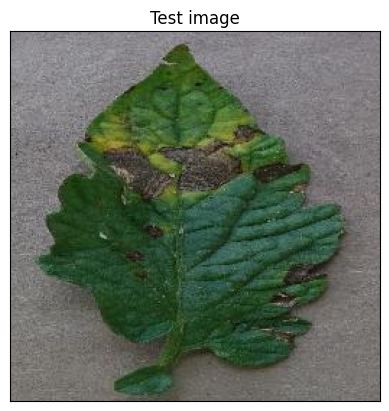

In [91]:
import cv2
img_path='C:\\Users\\Lenovo\\Documents\\CropDiseaseDetectionDataset\\test\\test\\Tomato___Early_blight (4).JPG'
img=cv2.imread(img_path)
img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title('Test image')
plt.xticks([])
plt.yticks([])
plt.show()

In [ ]:
image=tf.keras.preprocessing.image.load_img(img_path,target_size=(128,128))
input_arr=tf.keras.preprocessing.image.img_to_array(image)
input_arr=np.array([input_arr])#Convert single image to a batch(because model expects shape as (batch,row,col,depth))
print(input_arr.shape)

(1, 128, 128, 3)


In [93]:
prediction=model.predict(input_arr)
prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


array([[1.59954379e-05, 2.31166197e-08, 3.02629569e-03, 3.62370933e-08,
        4.57741400e-10, 4.80411400e-05, 4.18044988e-10, 4.02490332e-06,
        2.47297893e-09, 1.59778176e-06, 2.79228418e-10, 2.09387101e-04,
        4.54217752e-06, 3.11688054e-05, 4.73716222e-09, 2.09426041e-08,
        3.68998083e-03, 8.87624537e-07, 1.36504663e-04, 5.86251492e-09,
        7.44264471e-05, 3.46067623e-04, 3.57756963e-10, 3.96945632e-09,
        5.23095942e-11, 2.28645877e-06, 1.22428455e-05, 2.53333865e-09,
        2.78427452e-01, 7.06444085e-01, 3.36062070e-03, 4.15332443e-06,
        3.94090870e-03, 3.84345782e-08, 1.30349494e-04, 6.62917882e-05,
        7.87710519e-09, 2.27195342e-05]], dtype=float32)

In [94]:
result_index=np.argmax(prediction)
result_index

np.int64(29)

In [95]:
class_name=validation_set.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

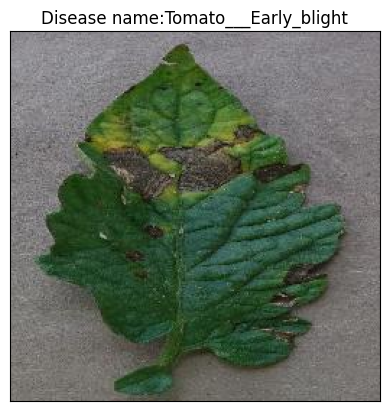

In [96]:
#Displaying result of disease prediction
model_prediction=class_name[result_index]
plt.imshow(img)
plt.title(f"Disease name:{model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()

*Testing on validation dataset*

In [32]:
test_set=tf.keras.utils.image_dataset_from_directory(
    "C:\\Users\\Lenovo\\Documents\\CropDiseaseDetectionDataset\\New Plant Diseases Dataset(Augmented)\\New Plant Diseases Dataset(Augmented)\\valid",
    labels="inferred",#Takes the name of the folders as the labels
    label_mode="categorical",#We have multiclass problem so categorical(e.g. binary or int is also available)
    class_names=None,
    color_mode="rgb",
    batch_size=32,#To speed up the process we can increase the batch size to 64 or 128
    image_size=(128, 128),
    shuffle=False,#If false then data will be feed in alphanumeric order
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    # format="tf",
    verbose=True,
)

Found 17572 files belonging to 38 classes.


In [47]:
class_name=test_set.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [33]:
y_pred=model.predict(test_set)
y_pred

550/550 ━━━━━━━━━━━━━━━━━━━━ 161s 293ms/step


array([[9.9996233e-01, 1.1855942e-05, 8.7266168e-09, ..., 3.2095741e-15,
        1.9372342e-11, 1.8797520e-12],
       [9.9999607e-01, 1.4426870e-06, 3.9671352e-07, ..., 1.8438423e-13,
        9.6070707e-10, 1.8110416e-12],
       [9.9950969e-01, 2.8000385e-04, 2.1456102e-05, ..., 1.3883217e-09,
        1.8915630e-07, 2.8176335e-09],
       ...,
       [4.5020829e-06, 9.7598485e-10, 1.0418308e-05, ..., 5.7202909e-04,
        2.6179336e-07, 9.8523456e-01],
       [1.7998047e-09, 1.3939772e-15, 1.3357168e-09, ..., 1.6410368e-05,
        4.7157826e-11, 9.9754250e-01],
       [1.8202474e-08, 9.4252245e-11, 1.6099332e-08, ..., 1.0979983e-06,
        9.8151634e-07, 8.3951873e-01]], shape=(17572, 38), dtype=float32)

In [34]:
predicted_categories=tf.argmax(y_pred,axis=1)#axis=1 for columnWise maximum
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], shape=(17572,))>

In [41]:
true_categories=tf.concat([y for x,y in test_set],axis=0)
print(true_categories)
true_categories=tf.argmax(true_categories,axis=1)
print(true_categories)

tf.Tensor(
[[1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]], shape=(17572, 38), dtype=float32)
tf.Tensor([ 0  0  0 ... 37 37 37], shape=(17572,), dtype=int64)


In [42]:
from sklearn.metrics import classification_report

In [49]:
print(classification_report(true_categories,predicted_categories,target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.91      0.94      0.93       504
                                 Apple___Black_rot       0.98      0.98      0.98       497
                          Apple___Cedar_apple_rust       0.93      0.95      0.94       440
                                   Apple___healthy       0.95      0.92      0.94       502
                               Blueberry___healthy       0.97      0.92      0.94       454
          Cherry_(including_sour)___Powdery_mildew       0.96      0.98      0.97       421
                 Cherry_(including_sour)___healthy       0.87      0.99      0.93       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.93      0.88      0.90       410
                       Corn_(maize)___Common_rust_       0.97      1.00      0.98       477
               Corn_(maize)___Northern_Leaf_Blight       0.88      0.93      0.

In [51]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(true_categories,predicted_categories)
cm

array([[472,   4,   0, ...,   0,   0,   0],
       [  1, 486,   0, ...,   0,   0,   0],
       [  0,   1, 419, ...,   0,   0,   5],
       ...,
       [  0,   0,   1, ..., 431,   0,   4],
       [  2,   0,   1, ...,   0, 418,   0],
       [  0,   0,   0, ...,   2,   0, 412]], shape=(38, 38))

*Confusion matrix visualization*

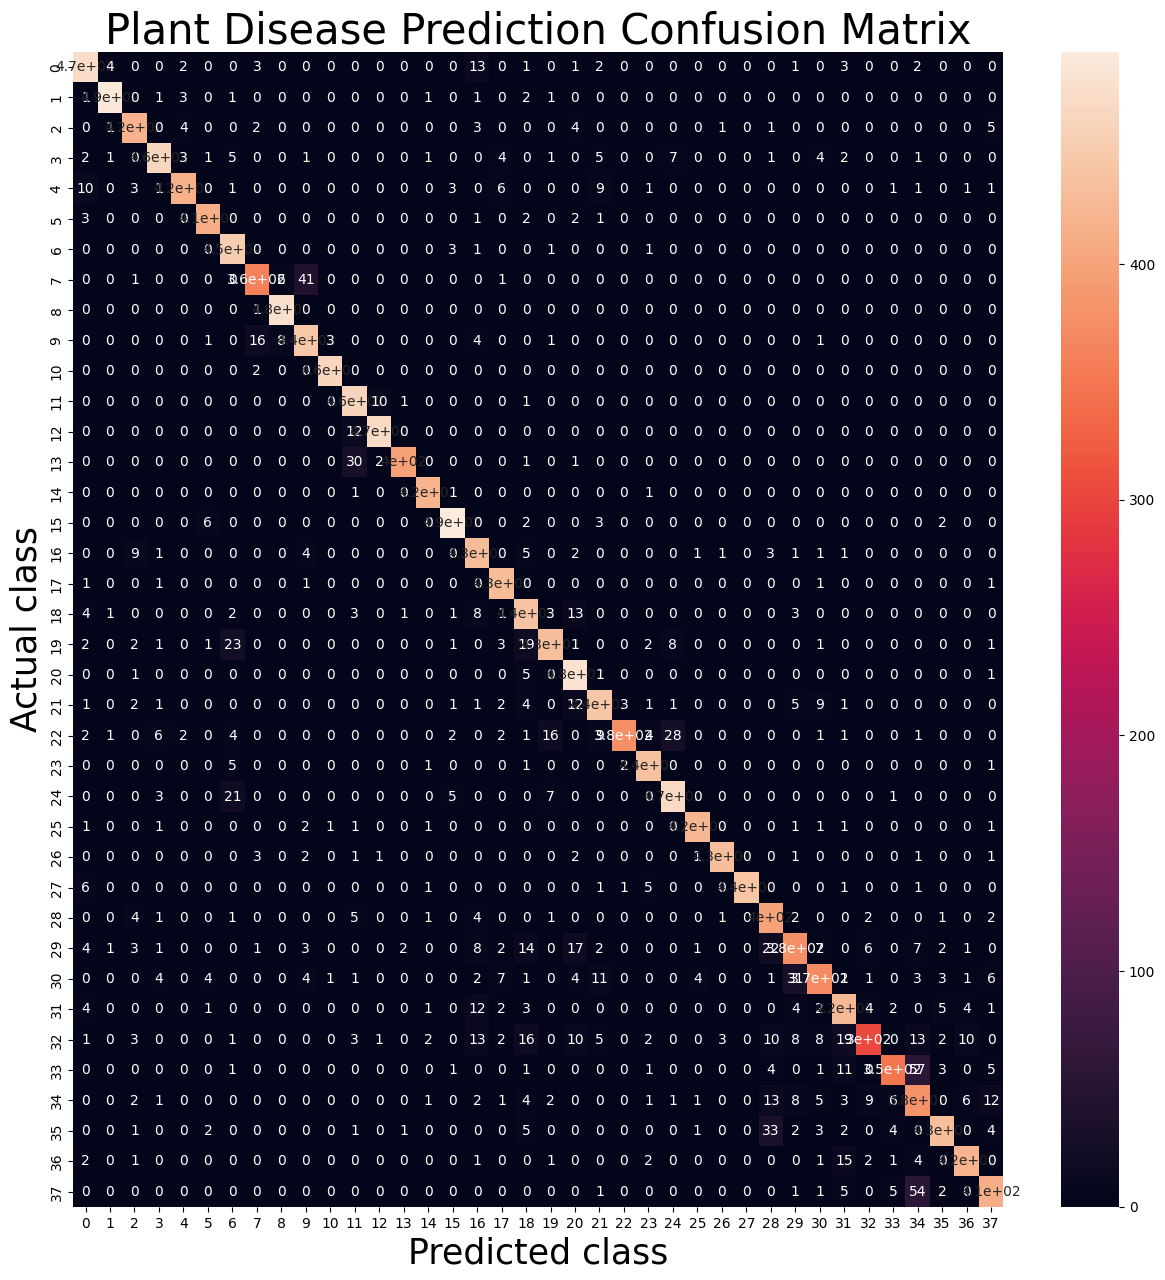

In [62]:
plt.figure(figsize=(15,15))
sns.heatmap(cm,annot=True)
plt.xlabel("Predicted class",fontsize=25)
plt.ylabel("Actual class",fontsize=25)
plt.title("Plant Disease Prediction Confusion Matrix",fontsize=30)
plt.show()